# 0 || Imports

In [1]:
#!pip install -qq ipython numpy pandas scikit-learn statsmodels xgboost torch

In [2]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import numpy as np
import pandas as pd
from pandas.api.types import is_integer_dtype
from pandas.tseries.holiday import USFederalHolidayCalendar

import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import xgboost
from xgboost import XGBRegressor

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
!python --version
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("torch", torch.__version__)

Python 3.10.18
numpy 2.2.6
pandas 2.3.3
scikit-learn 1.7.2
torch 2.9.1


# 1 || Data Processing and Feature Extraction

## 1.1 : Load the DataFrames

In [4]:
# Specify columns to extract.

ECOLS = [
    "UTC time",
    "Adjusted demand",
    "Adjusted net generation",
    "Adjusted total interchange",
    "FPC",
    "FMPP",
    "SOCO",
    "TEC",
    "JEA",
    "SEC",
    "HST",
    "GVL",
]

WCOLS = [
    "DATE",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlySeaLevelPressure",
    "HourlyStationPressure",
    "HourlyVisibility",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "HourlySkyConditions",
]


In [5]:
# Construct raw energy and weather datasets.

DFDICT = {
    subdir.name: { 
        csv.stem: pd.read_csv(csv, dtype="string", low_memory=False)
        for csv in subdir.glob("*.csv") 
    }
    for subdir in (Path.cwd() / "data").iterdir() if subdir.is_dir()
}

DFE = ( 
    DFDICT['electricity']['FPL'][ECOLS]
)
DFW = pd.concat(
    [DFDICT['weather']['MIA_20'+str(y)][WCOLS] for y in range(15, 26)],
    ignore_index=True
)


## 1.2 : Prepocessing and Missing Value Inspection

In [6]:
# Temporal columns are converted to datetime dtypes, adjusted to 
#  local time (UTC-5), and renamed 't'.
# Empty string or single space entries at set to N/A observations.
# Commas are removed from all values in the energy dataset.

DFE = ( DFE
    .assign(t=lambda df: pd.to_datetime(df["UTC time"]) - pd.Timedelta(hours=5))
    .drop(columns=["UTC time"])
    .replace(["", " "], pd.NA)
    .replace(",", "", regex=True)
)

DFW = ( DFW
    .assign(t=lambda df: pd.to_datetime(df["DATE"]))
    .drop(columns=["DATE"])
    .replace(["", " ", "*"], pd.NA)
)

# Drop the records in each dataset that are earlier or later than
#  all records in the other.

DFE = DFE[DFE["t"] <= DFW["t"].iloc[-1].round("d")]
DFW = DFW[DFW["t"] >= DFE["t"].iloc[0].normalize() - pd.Timedelta(days=1)]

# Merge both dataframes, joining electricity records to weather records
#  according to the nearest time measurement.

DF = pd.merge_asof(DFE, DFW, on="t", direction="nearest")


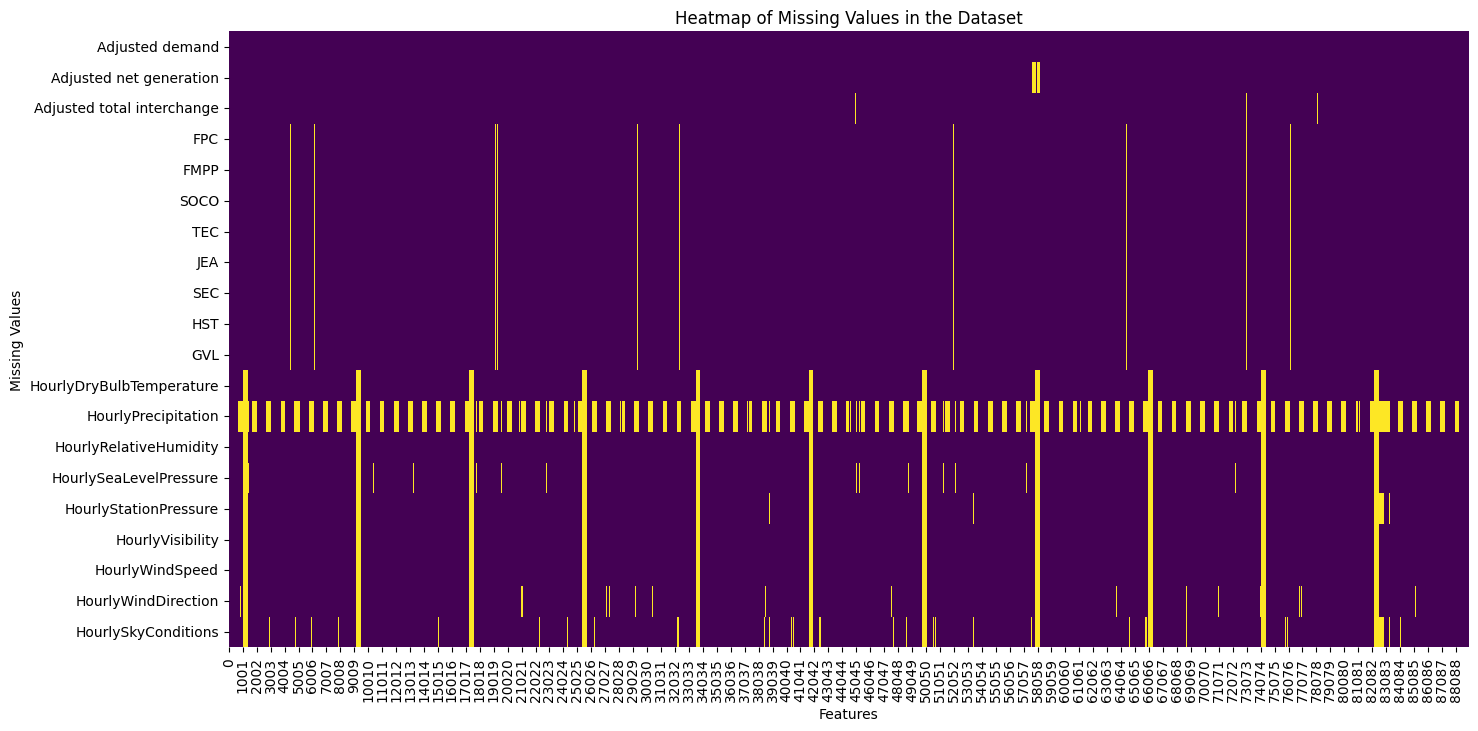

In [7]:
# Missing values heatmap.
plt.figure(figsize=(16, 8))
sns.heatmap(DF[ECOLS[1:]+WCOLS[1:]].isnull().T, cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values in the Dataset')
plt.xlabel('Features')
plt.ylabel('Missing Values')
plt.show()

In [8]:
# List proportions of missing values.
print("\n\t"+"="*20+" energyFeatures "+"="*20+"\n")
for col in ECOLS[1:]: 
    print(f"{col:>35}:" +" "*4 + f"{DF[col].isna().sum()/len(DF):.5f}")
print("\n\t"+"="*20+" weatherFeatures "+"="*20+"\n")
for col in WCOLS[1:]: 
    print(f"{col:>35}:" +" "*4 + f"{DF[col].isna().sum()/len(DF):.5f}")


	==================== energyFeatures ====================

                    Adjusted demand:    0.00027
            Adjusted net generation:    0.00593
         Adjusted total interchange:    0.00160
                                FPC:    0.00971
                               FMPP:    0.00971
                               SOCO:    0.00971
                                TEC:    0.00971
                                JEA:    0.00971
                                SEC:    0.00971
                                HST:    0.00971
                                GVL:    0.00971

	==================== weatherFeatures ====================

           HourlyDryBulbTemperature:    0.04171
                HourlyPrecipitation:    0.38413
             HourlyRelativeHumidity:    0.04174
             HourlySeaLevelPressure:    0.05588
              HourlyStationPressure:    0.04878
                   HourlyVisibility:    0.04167
                    HourlyWindSpeed:    0.04206
               

In [9]:
# Counts of streaks of missing values in each column.
missingStreakDict = { col: {} for col in ECOLS[1:]+WCOLS[1:] }
for col, _dict in missingStreakDict.items(): 
    mask = DF[col].isna()
    for _, run in mask.groupby((mask != mask.shift()).cumsum()):
        if not run.iloc[0]: continue
        _len = int(run.size)
        if _len not in _dict: _dict[_len] = []
        _dict[_len].append(run.index[0])
    width = max(len(f"=== {c} ===") for c in missingStreakDict.keys())
    header = f"=== {col} ===".center(width, "=")
    print(f"\n{header}\n")
    print( pd.Series({_len: len(idxList) for _len, idxList in _dict.items()})
             .sort_index()
             .rename_axis("Missing Streak Length")
             .reset_index(name="Count")
             .to_string(index=False)
    )


======== Adjusted demand =========

 Missing Streak Length  Count
                    24      1

==== Adjusted net generation =====

 Missing Streak Length  Count
                    24      1
                   216      1
                   288      1

=== Adjusted total interchange ===

 Missing Streak Length  Count
                     1      1
                     2      1
                    10      1
                    13      1
                    14      2
                    16      1
                    24      1
                    48      1

============== FPC ===============

 Missing Streak Length  Count
                     1      1
                    23      8
                    24     13
                    25      8
                    48      2
                    71      1

============== FMPP ==============

 Missing Streak Length  Count
                     1      1
                    23      8
                    24     13
                    25      8
     

In [10]:
# Count the number of rows with any missing features before any imputation
#  and after imputing all missing value gaps 1-3 hours long.
print("Rows with any NA (start):", 
      DF[ECOLS[1:]+WCOLS[1:]].isna().any(axis=1).sum())
_df = DF.copy()
for runLen in [1, 2, 3, 4, 5]:
    for col, run in missingStreakDict.items():
        if col not in WCOLS[1:]: continue
        if runLen not in run: continue
        fills = _df[col].ffill().bfill()
        for runIdx in run[runLen]:
            runIndices = range(runIdx, runIdx + runLen)
            _df.loc[runIndices, col] = fills.loc[runIndices]
    print(f"Rows with any NA (after len={runLen}):",
          _df[ECOLS[1:]+WCOLS[1:]].isna().any(axis=1).sum())

Rows with any NA (start): 35730
Rows with any NA (after len=1): 11157
Rows with any NA (after len=2): 2911
Rows with any NA (after len=3): 2750
Rows with any NA (after len=4): 2545
Rows with any NA (after len=5): 2474


## 1.3 : Imputation and Feature Construction

In [11]:
# # Unique value counts for sharp distributions observed above.
# pd.set_option("display.max_rows", None)
# for col in ["SEC", "HST", "HourlyPrecipitation", "HourlyVisibility", "HourlyWindSpeed"]:
#     print(f"\n=== {col} ===")
#     print(DF[col].value_counts(dropna=False).sort_index())

In [12]:
def plot_delta_distributions(df, cols):
    """
    For each column in `cols`, plot:
      - the value distribution
      - distributions of Δ over 1–4 hours, with σ_Δ / σ annotated.
    """
    
    for col in cols:
        fig, axes = plt.subplots(1, 5, figsize=(20, 3), sharey=True)
        vals = df[col].dropna()
        stdev = vals.std()
        axes[0].hist(vals, bins=30)
        axes[0].set_title(f"{col}\n(σ={stdev:.3g})")

        for i, h in enumerate(range(1, 5), start=1):
            if col == "HourlyWindDirection":
                angles = df[col].astype("float")
                diffs = ((angles - angles.shift(h) + 180) % 360) - 180
                diffs = diffs.dropna()
            else:
                diffs = df[col].diff(periods=h).dropna()
            axes[i].hist(diffs, bins=30)
            axes[i].set_title(
                f"Δ over {h}h\n"
                + "$\\sigma_{\\Delta}/\\sigma \\approx $"
                + f"{diffs.std()/stdev:.4f}"
            )

        fig.suptitle(f"Distributions for {col}")
        plt.tight_layout()

def impute_missing_streaks(df, cols, missingDict, runLengths=(1, 2)):
    """
    For each column in `cols`, impute missing values using interpolation for streaks whose 
     length is in `runLengths`, with special handling for HourlyWindDirection as circular data.
    Prints number of rows with any NA after each run length.
    """
    
    for col in cols:
        
        if col not in missingDict: continue
        runs = missingDict[col]
        dtypeFlag = is_integer_dtype(df[col].dtype)
        
        for _len in runLengths:
            
            if _len not in runs: continue
            startIndices = runs[_len]
            if col == "HourlyWindDirection":
                rads = np.deg2rad(df[col].astype("float"))
                sinRads = np.sin(rads).interpolate(limit_direction="both")
                cosRads = np.cos(rads).interpolate(limit_direction="both")
                interpolations = np.rad2deg(np.arctan2(sinRads, cosRads)) % 360
            else:
                interpolations = df[col].interpolate(limit_direction="both")
            if dtypeFlag: interpolations = interpolations.round()
            
            for idx in startIndices:
                runIndices = range(idx, idx + _len)
                df.loc[runIndices, col] = interpolations.loc[runIndices]
                if col == "HourlyWindDirection":
                    df.loc[runIndices, "HourlyWindDirection_Flag_VRB"] = False


In [13]:
# AUTOREGRESSIVE (LAG) FEATURES

DF["Adjusted demand"] = DF["Adjusted demand"].astype("Int32")
lags = sorted(set(
    list(range(1, 7)) + [12, 18]
    + list(range(24, 27)) + [36, 48]
    + [24*i for i in range(3,7)]
    + [24*7*i for i in range(1,5)]
))
for h in lags: DF[f"Adjusted demand -{h} hr"] = DF["Adjusted demand"].shift(h)
lagFeatures = [f"Adjusted demand -{h} hr" for h in lags]


In [14]:
# CALENDAR FEATURES

# Create raw integer calendar features
intDateTimeFeatures = ["Hour", "Month", "DayOfWeek", "DayOfYear"]
DF["Hour"] = DF["t"].dt.hour.astype("Int8")
DF["Month"] = DF["t"].dt.month.astype("Int8")
DF["DayOfWeek"] = DF["t"].dt.dayofweek.astype("Int8")
DF["DayOfYear"] = DF["t"].dt.dayofyear.astype("Int16")

# Low order hour of day and day of year Fourier term features
hourFourierFeatures, dayFourierFeatures = [], []
for i in (1, 2, 3):
    rads = np.pi * DF["Hour"] / 12
    argStr = (f"{i}*" if i>1 else "") + "Hour"
    hourFourierFeatures.extend([f"sin({argStr})", f"cos({argStr})"])
    DF[f"sin({argStr})"] = np.sin(rads).astype("float32")
    DF[f"cos({argStr})"] = np.cos(rads).astype("float32")
    rads = np.pi * i * DF["DayOfYear"] / 182.625
    argStr = (f"{i}*" if i>1 else "") + "DayOfYear"
    dayFourierFeatures.extend([f"sin({argStr})", f"cos({argStr})"])
    DF[f"sin({argStr})"] = np.sin(rads).astype("float32")
    DF[f"cos({argStr})"] = np.cos(rads).astype("float32")

# Hour of day and day of week one-hot encodings.
# Weekend and holiday flags.
hourDummyFeatures = [f"Hour_Flag_{h}" for h in range(24)]
dayDummyFeatures = ["Day_Flag_Weekend", "Day_Flag_Holiday"]
dayDummyFeatures += [f"DayOfWeek_Flag_{d}" for d in range(7)]
monthDummyFeatures = [f"Month_Flag_{m}" for m in range(1, 13)]
DF["Day_Flag_Weekend"] = (DF["DayOfWeek"] >= 5).astype("bool")
DF["Day_Flag_Holiday"] = DF["t"].dt.date.isin(
    USFederalHolidayCalendar().holidays(
        start=DF["t"].min().date(),
        end=DF["t"].max().date()
    ).date
)
DF = pd.concat([ DF,
    pd.get_dummies(DF["Hour"], prefix="Hour_Flag"),
    pd.get_dummies(DF["DayOfWeek"], prefix="DayOfWeek_Flag"),
    pd.get_dummies(DF["Month"], prefix="Month_Flag")
], axis=1)

# Collate all calendar features
calendarFeatures = (
    intDateTimeFeatures
    + hourFourierFeatures
    + dayFourierFeatures
    + hourDummyFeatures
    + dayDummyFeatures
    + monthDummyFeatures
)


In [15]:
# ENERGY FEATURES

# Convert to numeric types.
for i, col in enumerate(ECOLS[2:]):
    DF[col] = DF[col].astype("Int16" if i else "Int32")

# Set extremely anomalous values to null.
DF.loc[DF["SEC"].eq(2465), "SEC"] = pd.NA
DF.loc[DF["HST"].eq(-2278), "HST"] = pd.NA

# Collate energy features. 
energyFeatures = ECOLS[2:]


In [16]:
# WEATHER FEATURES

# Construct indicator flags for observations indicated with
#  suspicious values and variable visibility.
# Remove those alpha characters from those observations.

colsWithFlags = [
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlySeaLevelPressure",
    "HourlyStationPressure",
    "HourlyVisibility",
]

for col in colsWithFlags:
    ch = "V" if (col == "HourlyVisibility") else "s"
    mask = DF[col].str.endswith(ch)
    DF[f"{col}_Flag_{ch}"] = mask
    DF.loc[mask, col] = DF.loc[mask, col].str[:-1]

# Construct an indicator flag for VRB wind direction observations
#  and set those observations to be N/A.

mask = DF["HourlyWindDirection"].eq("VRB")
DF["HourlyWindDirection_Flag_VRB"] = mask
DF.loc[mask, "HourlyWindDirection"] = pd.NA

# Replace trace precipiataion observations with a reasonable numeric value.

DF["HourlyPrecipitation"] = DF["HourlyPrecipitation"].replace("T", "0.0025")

# Convert columns to appropriate numeric types.

floatFeatures = [
    "HourlyPrecipitation",
    "HourlySeaLevelPressure",
    "HourlyStationPressure",
    "HourlyVisibility",
]
for col in WCOLS[1:-1]:
    if col in floatFeatures: DF[col] = DF[col].astype("Float32")
    else: DF[col] = DF[col].astype("Int16")

# Set extremely anomalous values to null.
# Impute missing values.

DF.loc[DF["HourlyWindSpeed"].eq(2237), "HourlyWindSpeed"] = pd.NA
impute_missing_streaks(DF, WCOLS[1:-1], missingStreakDict)

# Construct circular (float) and cardinal (one-hot) encodings from
#  imputed HourlyWindDirection columns.

rads = np.deg2rad(DF["HourlyWindDirection"].astype("Float32"))
DF["sin(HourlyWindDirection)"] = np.sin(rads)
DF["cos(HourlyWindDirection)"] = np.cos(rads)
DF.loc[mask, ["sin(HourlyWindDirection)", "cos(HourlyWindDirection)"]] = 0.0

directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
for i, d in enumerate(directions):
    DF[f"HourlyWindDirection_Flag_{d}"] = (
        (((22.5 + DF["HourlyWindDirection"]) % 360) // 45).astype("Int8").eq(i)
    )
    DF.loc[mask, f"HourlyWindDirection_Flag_{d}"] = False

# Collate all weather features.

weatherFeatures = (
    WCOLS[1:-1]
    + [col + "_Flag_s" for col in colsWithFlags[:-1]]
    + ["HourlyVisibility_Flag_V", "HourlyWindDirection_Flag_VRB"]
    + ["HourlyWindDirection_Flag_" + d for d in directions]
    + ["sin(HourlyWindDirection)", "cos(HourlyWindDirection)"]
)


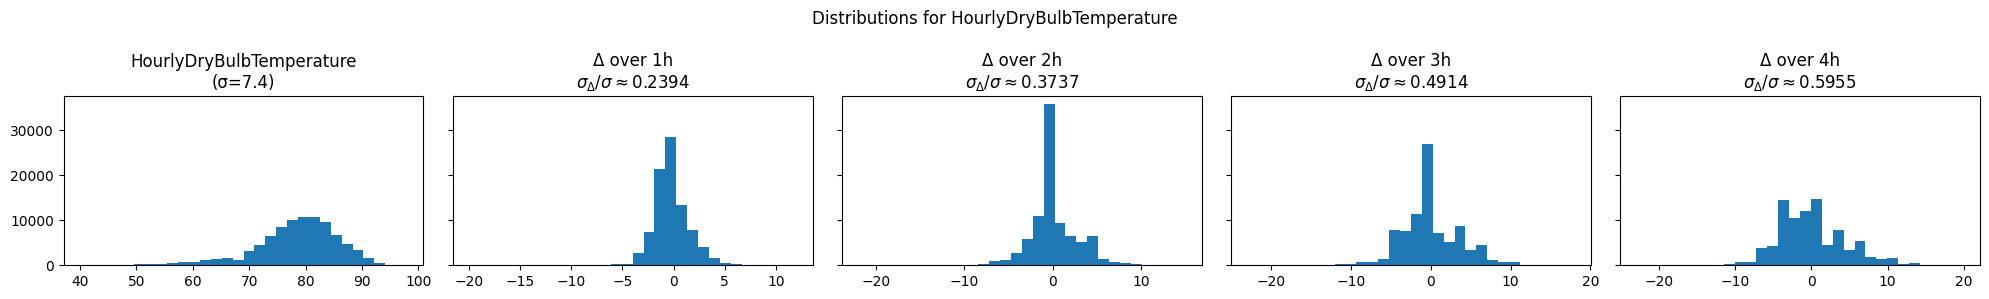

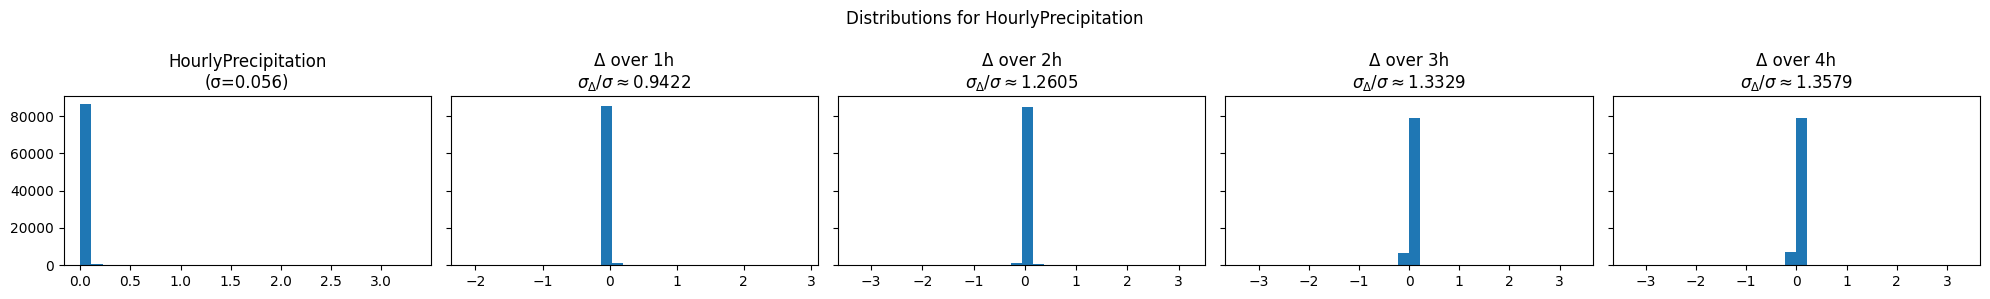

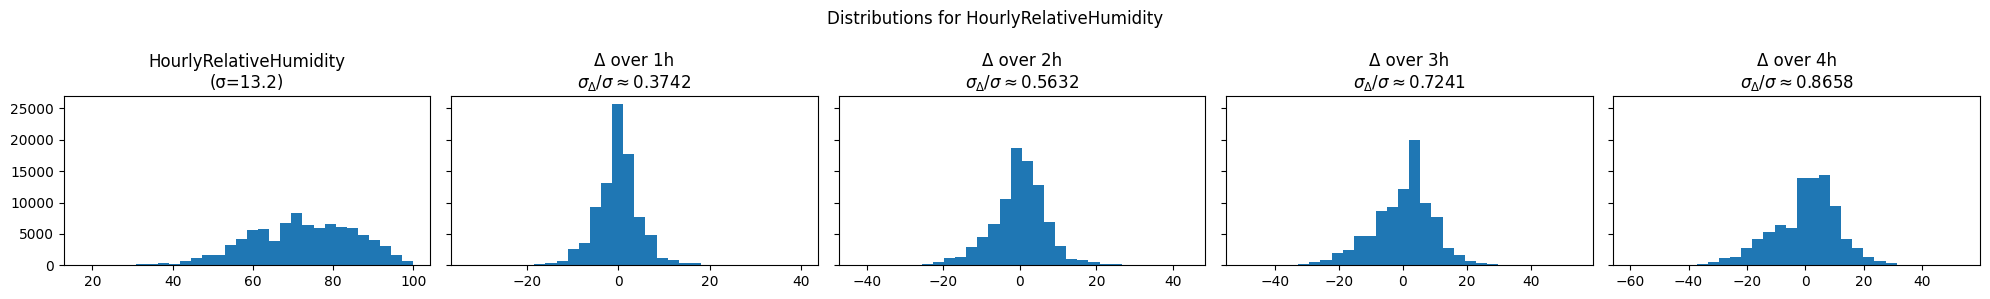

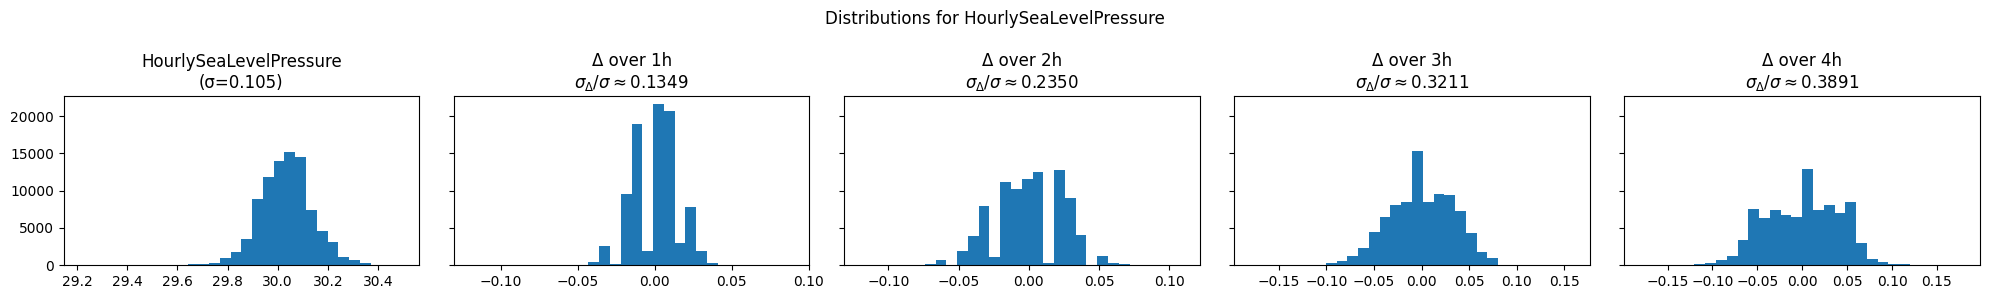

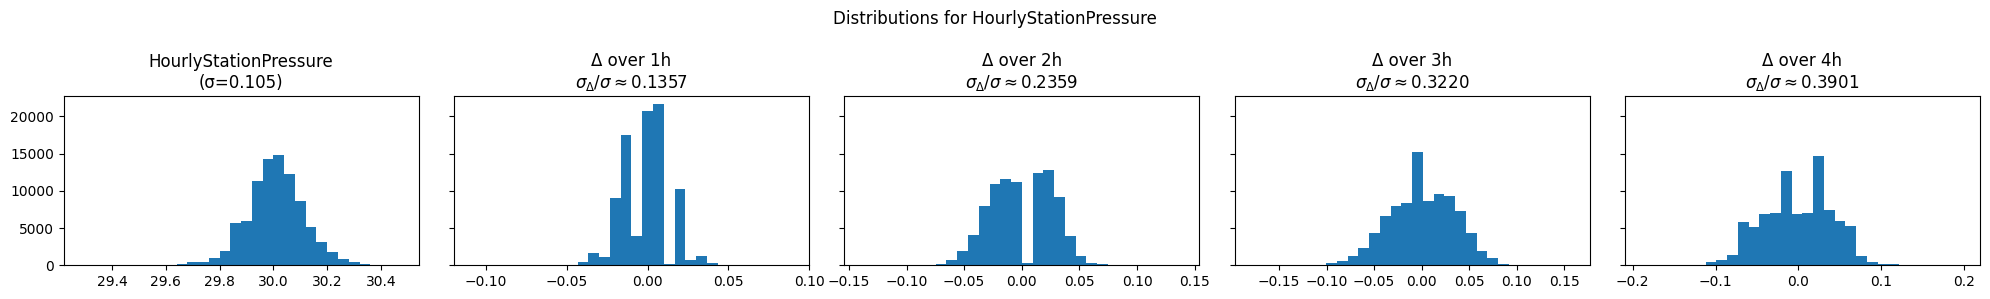

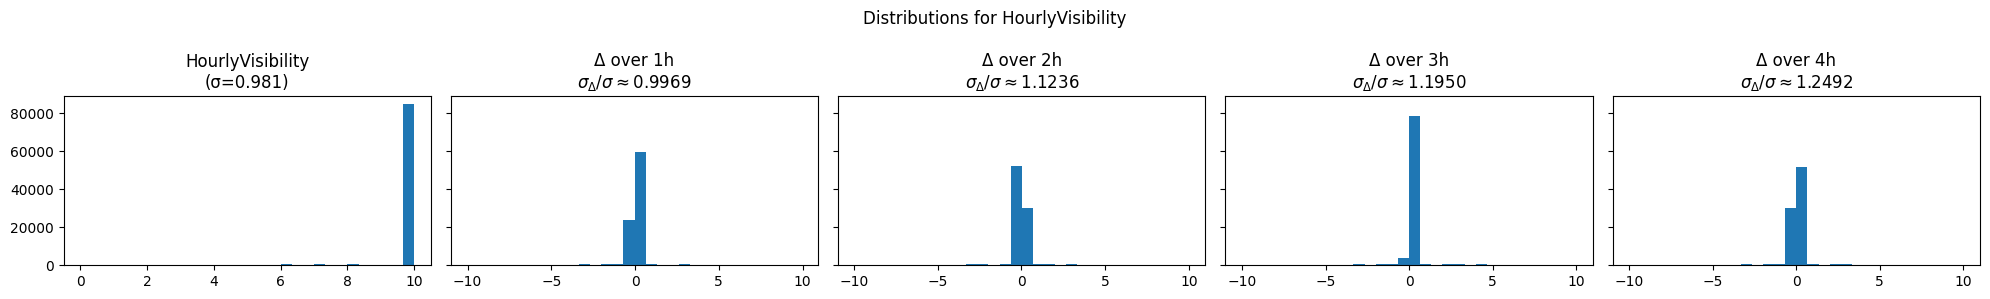

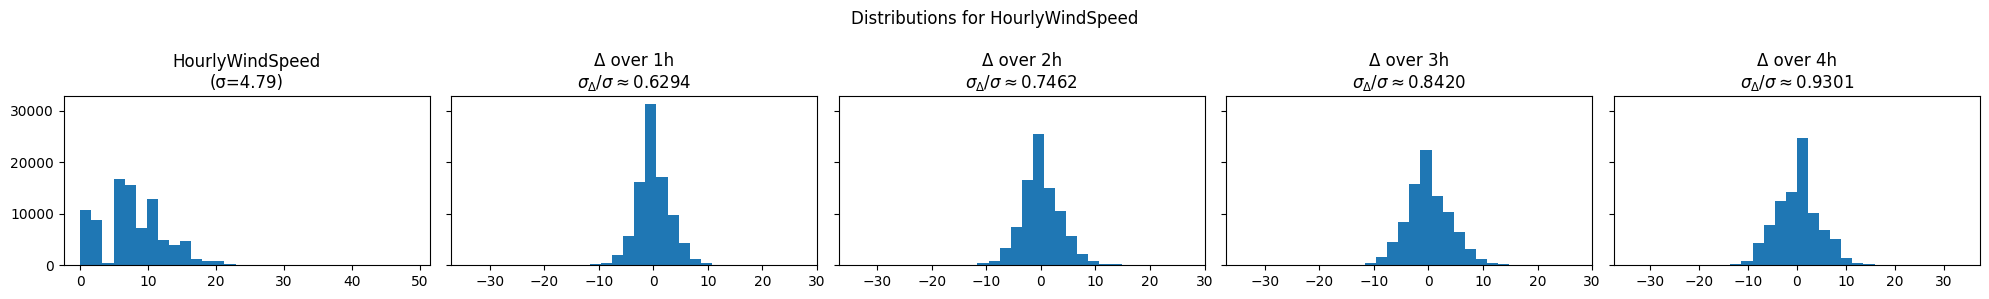

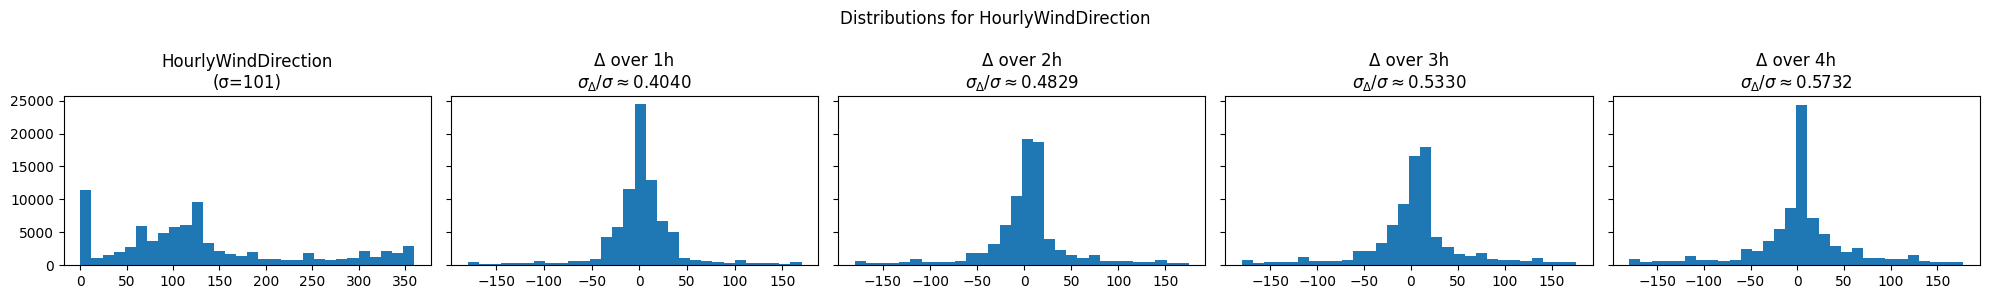

In [17]:
plot_delta_distributions(DF, WCOLS[1:-1])

In [18]:
for f in weatherFeatures:
    print(f, DF[f].dtype, min(DF[f].dropna()), max(DF[f].dropna()))

HourlyDryBulbTemperature Int16 40 98
HourlyPrecipitation Float32 0.0 3.33
HourlyRelativeHumidity Int16 17 100
HourlySeaLevelPressure Float32 29.21 30.5
HourlyStationPressure Float32 29.28 30.48
HourlyVisibility Float32 0.0 10.0
HourlyWindSpeed Int16 0 49
HourlyWindDirection Int16 0 360
HourlyDryBulbTemperature_Flag_s boolean False True
HourlyPrecipitation_Flag_s boolean False True
HourlySeaLevelPressure_Flag_s boolean False True
HourlyStationPressure_Flag_s boolean False True
HourlyVisibility_Flag_V boolean False True
HourlyWindDirection_Flag_VRB boolean False True
HourlyWindDirection_Flag_N boolean False True
HourlyWindDirection_Flag_NE boolean False True
HourlyWindDirection_Flag_E boolean False True
HourlyWindDirection_Flag_SE boolean False True
HourlyWindDirection_Flag_S boolean False True
HourlyWindDirection_Flag_SW boolean False True
HourlyWindDirection_Flag_W boolean False True
HourlyWindDirection_Flag_NW boolean False True
sin(HourlyWindDirection) Float32 -1.0 1.0
cos(HourlyWind

In [19]:
# Define other convenient feature variables.

target = "Adjusted demand"
allFeatures = (
    lagFeatures + calendarFeatures 
    + energyFeatures + weatherFeatures
)


In [20]:
checkFeatures = ECOLS[1:]+WCOLS[1:-2]+["HourlyWindDirection_Flag_VRB"]
print("Rows with any NA:", DF[checkFeatures].isna().any(axis=1).sum())

Rows with any NA: 2909


In [21]:
# Counts of streaks of missing values in each column.
checkStreakDict = { col: {} for col in checkFeatures }
for col, _dict in checkStreakDict.items(): 
    mask = DF[col].isna()
    for _, run in mask.groupby((mask != mask.shift()).cumsum()):
        if not run.iloc[0]: continue
        _len = int(run.size)
        if _len not in _dict: _dict[_len] = []
        _dict[_len].append(run.index[0])
    width = max(len(f"=== {c} ===") for c in checkStreakDict.keys())
    header = f"=== {col} ===".center(width, "=")
    print(f"\n{header}\n")
    print( pd.Series({_len: len(idxList) for _len, idxList in _dict.items()})
             .sort_index()
             .rename_axis("Missing Streak Length")
             .reset_index(name="Count")
             .to_string(index=False)
    )


========= Adjusted demand ==========

 Missing Streak Length  Count
                    24      1

===== Adjusted net generation ======

 Missing Streak Length  Count
                    24      1
                   216      1
                   288      1

==== Adjusted total interchange ====

 Missing Streak Length  Count
                     1      1
                     2      1
                    10      1
                    13      1
                    14      2
                    16      1
                    24      1
                    48      1

=============== FPC ================

 Missing Streak Length  Count
                     1      1
                    23      8
                    24     13
                    25      8
                    48      2
                    71      1

=============== FMPP ===============

 Missing Streak Length  Count
                     1      1
                    23      8
                    24     13
                    25   

In [22]:
DFclean = DF.dropna()
print(len(DF)), print(len(DFclean))

89017
49404


(None, None)